# CNN model to predict corners of the board


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:  ", device)

Using device:   cuda


# Model MYCNN


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNNcorner(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, stride=1, padding=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2)

        # make spatial size fixed to 7x7 no matter the input
        self.gap = nn.AdaptiveAvgPool2d((7, 7))

        self.fc1 = nn.Linear(64 * 7 * 7, 512)
        self.fc2 = nn.Linear(512, 8)  # (x1,y1,x2,y2,x3,y3,x4,y4)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)   # /2
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)   # /4
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)   # /8

        x = self.gap(x)          # -> (B,64,7,7)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)          # raw coordinates (we’ll train on normalized)
        return x


# Model RESNET

In [67]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

class ResNetCorner(nn.Module):
    def __init__(self, freeze_backbone=False):
        super().__init__()

        # Pretrained ResNet18
        self.backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

        # Optionally freeze early layers
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        in_features = self.backbone.fc.in_features

        # Replace classification head with a small regression head
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 8)   # 4 corners * (x, y) in [0,1]
        )

    def forward(self, x):
        return self.backbone(x)


# Model EfficientNet

In [69]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

class EfficientNetCorner(nn.Module):
    def __init__(self, freeze_backbone: bool = False):
        super().__init__()

        # Pretrained EfficientNet-B0
        self.backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        in_features = self.backbone.classifier[1].in_features  # final FC size

        # Replace classifier with regression head
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.2, inplace=True),
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 8),  # 4 corners * (x,y)
        )

    def forward(self, x):
        return self.backbone(x)


# Model HRNet

In [11]:
import torch
import torch.nn as nn
import timm

class HRNetCorner(nn.Module):
    def __init__(self, pretrained: bool = True, freeze_backbone: bool = False):
        super().__init__()

        self.backbone = timm.create_model(
            "hrnet_w18",
            pretrained=pretrained,
            features_only=True,
            out_indices=[-1],
        )

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        in_chs = self.backbone.feature_info[-1]["num_chs"]  # <— important

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.head = nn.Sequential(
            nn.Linear(in_chs, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 8),
        )

    def forward(self, x):
        feat = self.backbone(x)[0]          # (B, C, H, W)
        x = self.pool(feat).flatten(1)      # (B, C)
        x = self.head(x)                    # (B, 8)
        return x


/mnt/D/University/Thesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Dataset

In [3]:
import os, json
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
import torch

class ChessboardCornersDataset(Dataset):
    def __init__(self, images_root, annotation_file, transform=None):
        self.images_root = images_root
        self.transform = transform

        with open(annotation_file, "r") as f:
            self.ann = json.load(f)

        self.img_names = list(self.ann.keys())

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.images_root, img_name)

        img = Image.open(img_path).convert("RGB")

        pts = torch.tensor(self.ann[img_name], dtype=torch.float32)  # (4, 2)
        coords = pts.view(-1)  # (8,) -> [x1,y1,x2,y2,x3,y3,x4,y4]

        if self.transform is not None:
            img = self.transform(img)

        return img, coords


# Edgeeeee

In [4]:
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms

class CannyEdge:
    def __init__(self, t1=100, t2=200):
        self.t1 = t1
        self.t2 = t2

    def __call__(self, img: Image.Image) -> Image.Image:
        # img: PIL RGB
        gray = np.array(img.convert("L"))
        edges = cv2.Canny(gray, self.t1, self.t2)  # H x W, uint8

        # replicate to 3 channels so model input stays (3, H, W)
        edges_3 = np.stack([edges, edges, edges], axis=-1)
        return Image.fromarray(edges_3)


# DataLoading

In [19]:
from torchvision import transforms
from torch.utils.data import random_split, DataLoader


images_dir = "Tagroba Kibeera Awy/big_Images"
annotations_dir = "Tagroba Kibeera Awy/big_annotations.json"

tfm = transforms.Compose([
    transforms.Resize((256,256)),
    # transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    CannyEdge(t1=100, t2=200),
    # transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0),
    # transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
])

# train_ds = ChessboardCornersDataset(
#     images_root=images_dir,
#     annotation_file=annotations_dir,
#     transform=tfm
# )


# full_ds = ChessboardCornersDataset(
#     images_root=images_dir,
#     annotation_file=annotations_dir,
#     transform=tfm,
# )

# val_ratio = 0.2
# n_total = len(full_ds)
# n_val = int(n_total * val_ratio)
# n_train = n_total - n_val

# train_ds, val_ds = random_split(full_ds, [n_train, n_val])

# num_workers = 2
# train_dl = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=num_workers, pin_memory=True)
# val_dl   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=num_workers, pin_memory=True)


# Train Loop

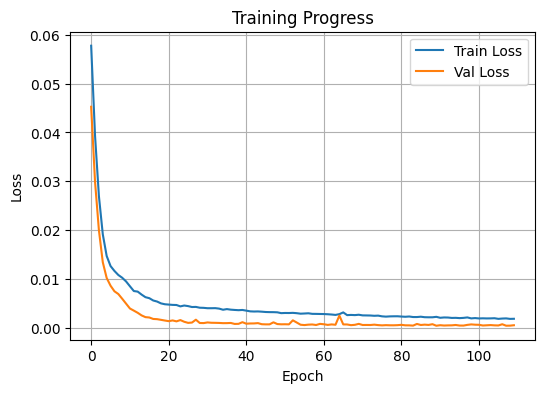

Epoch 114: train=0.00184, val=0.00052
Early stopping triggered.


In [133]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import clear_output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = CNNcorner().to(device)
# model = ResNetCorner(freeze_backbone=False).to(device)
# model = EfficientNetCorner(freeze_backbone=False).to(device)
model = HRNetCorner(pretrained=True, freeze_backbone=False).to(device)
# criterion = nn.MSELoss()
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=5e-5)

num_epochs = 150
patience = 20
best_val_loss = float("inf")
epochs_no_improve = 0
best_state = None

train_hist = []
val_hist = []

for epoch in range(num_epochs):

    # ---- train ----
    model.train()
    train_loss = 0.0
    for imgs, targets in train_dl:
        imgs = imgs.to(device)
        targets = targets.to(device)

        preds = model(imgs)
        loss = criterion(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)

    train_loss /= len(train_dl.dataset)

    # ---- validate ----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, targets in val_dl:
            imgs = imgs.to(device)
            targets = targets.to(device)
            preds = model(imgs)
            loss = criterion(preds, targets)
            val_loss += loss.item() * imgs.size(0)

    val_loss /= len(val_dl.dataset)

    if epoch > 3:
        train_hist.append(train_loss)
        val_hist.append(val_loss)

    # ---- live plot ----
    clear_output(wait=True)
    plt.figure(figsize=(6,4))
    plt.plot(train_hist, label="Train Loss")
    plt.plot(val_hist, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Progress")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Epoch {epoch+1}: train={train_loss:.5f}, val={val_loss:.5f}")

    # ---- early stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_state = model.state_dict()
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered.")
            break

# ---- load best model ----
if best_state is not None:
    model.load_state_dict(best_state)


In [ ]:
#save the best model
torch.save(model.state_dict(), "synthetic_cnn_chessboard_corners.pth")


In [14]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNcorner().to(device)
# model = ResNetCorner().to(device)
# model = HRNetCorner().to(device)
model.load_state_dict(torch.load("SOBELcnn1_chessboard_corners.pth", map_location=device))
model.eval()


CNNcorner(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (gap): AdaptiveAvgPool2d(output_size=(7, 7))
  (fc1): Linear(in_features=3136, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=8, bias=True)
)

# Check annotations

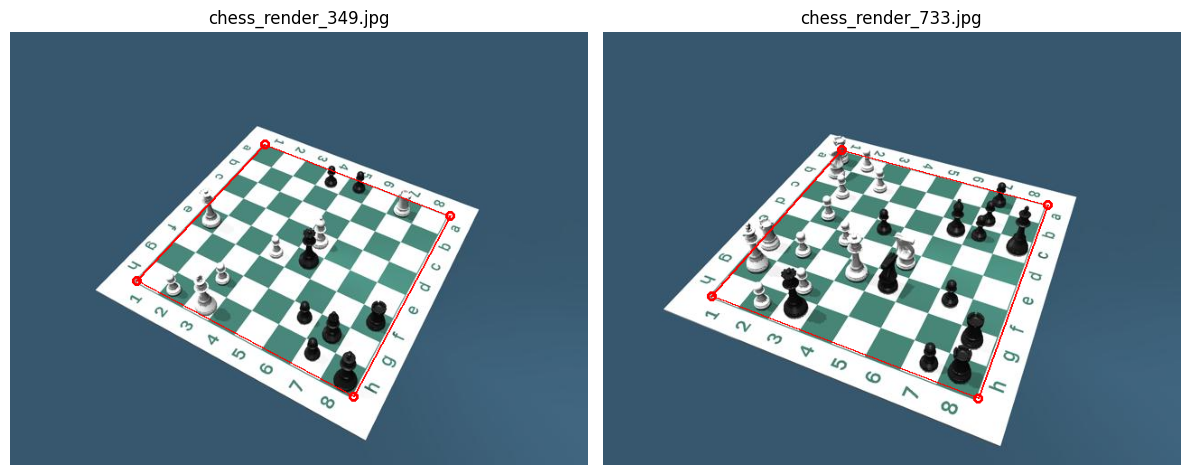

In [ ]:
import json
import random
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import os

def visualize_random_samples(json_path="synthetic/annotations.json",
                             images_root="synthetic/Images",
                             num_samples=5):
    
    # load JSON
    with open(json_path, "r") as f:
        ann = json.load(f)

    image_names = list(ann.keys())

    # pick random images
    sample_names = random.sample(image_names, min(num_samples, len(image_names)))



    plt.figure(figsize=(12, 12))

    for i, img_name in enumerate(sample_names):
        img_path = os.path.join(images_root, img_name)
        pts = ann[img_name]  # list of [x,y] normalized

        img = Image.open(img_path).convert("RGB")
        W, H = img.size
        
        # convert normalized → pixel coords
        pix_pts = [(x * W, y * H) for x, y in pts]

        # draw
        draw = ImageDraw.Draw(img)
        for x, y in pix_pts:
            r = 5
            draw.ellipse((x-r, y-r, x+r, y+r), outline="red", width=3)

        # draw polygon (close it)
        draw.line(pix_pts + [pix_pts[0]], fill="red", width=2)

        # plot
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.title(img_name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Example call:
visualize_random_samples("synthetic/annotations.json", "synthetic/Images", num_samples=2)


# Testing

In [27]:
import torch
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from torchvision import transforms

def visualize_prediction(image_path, model, device="cuda"):
    model.eval()

    # Load image
    img_pil = Image.open(image_path).convert("RGB")
    w, h = img_pil.size


    # Preprocess
    img_t = tfm(img_pil).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        pred = model(img_t)[0].cpu()  # (8,)
        print(pred)

    # Convert normalized -> pixel coords
    xs = (pred[0::2] * w).tolist()
    ys = (pred[1::2] * h).tolist()
    corners = list(zip(xs, ys))


    #9x9 grid using the corners predicted from the model to overlay on the image


    # Draw
    draw_img = img_pil.copy()
    draw = ImageDraw.Draw(draw_img)

    for (x, y) in corners:
        r = 6
        draw.ellipse((x-r, y-r, x+r, y+r), outline="red", width=2)

    draw.line(corners + [corners[0]], fill="red", width=2)

    # Matplotlib
    plt.figure(figsize=(6, 6))
    plt.imshow(draw_img)
    plt.axis("off")
    plt.show()

    return pred


In [32]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def gridify(inp, img):
    # ---- Input: 4 corner points as tensor ----
    # Order: TL, TR, BR, BL

    img = Image.open(img).convert("RGB")
        # Reshape into 4 corner points: TL, TR, BR, BL
    corners = inp.reshape(4, 2)

    # ---- Create a 9×9 bilinearly-interpolated grid ----
    t = torch.linspace(0, 1, 9)
    s = torch.linspace(0, 1, 9)

    grid = []
    for ti in t:
        # left and right edges interpolation
        left  = corners[0] * (1 - ti) + corners[3] * ti
        right = corners[1] * (1 - ti) + corners[2] * ti

        for si in s:
            p = left * (1 - si) + right * si
            grid.append(p)

    grid = torch.stack(grid)   # shape: (81, 2)

    print("Grid shape:", grid.shape)
    print(grid[:5])  # first few points

    # ---- Plot on a blank image ----
    # img = np.ones((1,1,3))  # small dummy image — grid is in normalized coords

    plt.figure(figsize=(6,6))
    plt.imshow(img, extent=[0,1,1,0])  # match normalized coordinate system
    plt.scatter(grid[:,0], grid[:,1], s=30)
    plt.scatter(corners[:,0], corners[:,1], c='red', s=50)  # corners
    plt.title("9×9 Grid From Corner Points")
    plt.show()

tensor([0.2917, 0.2465, 0.7174, 0.2218, 0.8943, 0.7171, 0.2205, 0.8071])


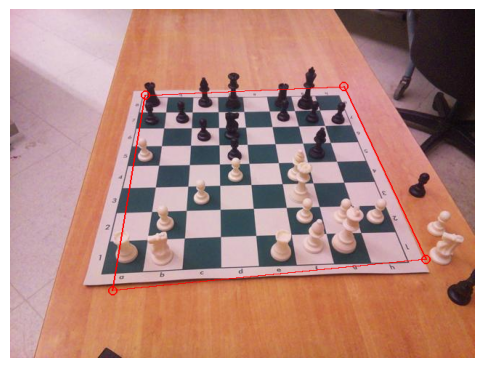

Grid shape: torch.Size([81, 2])
tensor([[0.2917, 0.2465],
        [0.3449, 0.2434],
        [0.3981, 0.2403],
        [0.4513, 0.2372],
        [0.5045, 0.2342]])


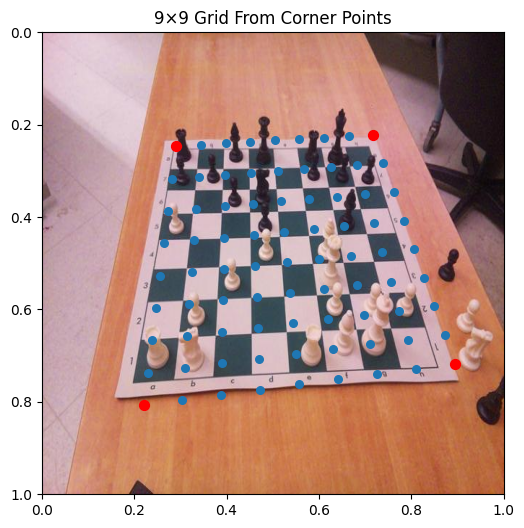

In [33]:
import random

#select random image from zzzNewimgs folder


# img = random.choice(os.listdir("synthetic/Images"))
# img = "synthetic/Images/" + img
# print("Visualizing:", img)
# visualize_prediction(img, model, device=device)
img = "/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset4/Images/image_29.jpg"
corners = visualize_prediction(img, model, device=device)
gridify(corners, img)
# print(corners)
# visualize_prediction("WhatsApp Image 2025-11-22 at 11.14.12 PM.jpeg", model, device=device)


In [ ]:
# print model size in MB
model_size = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f"Model size: {model_size:.2f} million parameters")
print(f"Model size: {model_size*4/1024:.2f} MB")  # assuming float32 (4 bytes each)

import time
import torch

# --- prepare a sample batch (1 image) ---
dummy_img, _ = next(iter(val_dl))   # 1 batch from val
dummy_img = dummy_img[0].unsqueeze(0).to(device)   # make it [1,3,256,256]

model.eval()
torch.cuda.empty_cache()

# --- warm-up (important for GPU) ---
with torch.no_grad():
    for _ in range(10):
        _ = model(dummy_img)

# --- measure inference time ---
N = 100
torch.cuda.synchronize()
t0 = time.time()

with torch.no_grad():
    for _ in range(N):
        _ = model(dummy_img)
torch.cuda.synchronize()

dt = (time.time() - t0) / N
print(f"Inference time per image: {dt*1000:.2f} ms  ({1/dt:.1f} FPS)")


Model size: 1.68 million parameters
Model size: 0.01 MB
Inference time per image: 0.56 ms  (1772.0 FPS)
